# Most active users

In [2]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
# Load the dataset
# import datasets
df = pd.read_json("../../Datasets/voluntariosdanavalencia_old.json") # Import data from Voluntarios de Valencia groupchat.

In [4]:
# Check data structure
print(df.shape)
print(df.columns)
df.head()

(18064, 17)
Index(['id', 'date', 'message', 'reply_to_msg_id', 'views', 'forwards',
       'edit_date', 'pinned', 'post_author', 'sender_id', 'sender_username',
       'sender_name', 'has_media', 'reactions', 'subgroup', 'topic_name',
       'reply'],
      dtype='object')


,id,date,message,reply_to_msg_id,views,forwards,edit_date,pinned,post_author,sender_id,sender_username,sender_name,has_media,reactions,subgroup,topic_name,reply
0,3,2024-10-30 12:39:24+00:00,Os paso por aquí el correo,NaN,NaN,NaN,None,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,False,[],None,Discusión general,False
1,4,2024-10-30 12:40:50+00:00,LO AVISÉ EL VIERNES PASADO Y NADIE ME HIZO CAS...,NaN,46823.0,1057.0,2024-11-01T18:21:38+00:00,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,True,"[{'user_id': 5887977931, 'username': '', 'disp...",None,Discusión general,False
2,5,2024-10-30 12:43:17+00:00,,NaN,NaN,NaN,2024-11-03T22:44:05+00:00,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,True,"[{'user_id': 6970134793, 'username': '', 'disp...",None,Discusión general,False
3,6,2024-10-30 12:43:23+00:00,Probad si podeis,NaN,NaN,NaN,None,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,False,[],None,Discusión general,False
4,7,2024-10-30 12:46:02+00:00,Durante la tormenta al parecer sí estaba opera...,4.0,NaN,NaN,None,False,NaN,941865373,Camelocota,Víctor Conejero,False,[],Thread_4,Discusión general,True


## Most Active Users

In [5]:
# Rank users by message count
user_message_counts = df['sender_id'].value_counts()
print(user_message_counts.head(10))

sender_id
1762777403    441
7094531229    432
1505404600    388
271855505     347
6973904485    339
6601816159    298
6221273187    278
1095473116    237
5689570195    232
1151037126    230
Name: count, dtype: int64


A lo mejor debería anonimizar los datos.

In [6]:
# total number of messages
total_messages = len(df)
print(f"Total number of messages: {total_messages}")

# number of unique users
unique_users = df['sender_id'].nunique()
print(f"Number of unique users: {unique_users}")

# average messages per user
average_messages_per_user = total_messages / unique_users
print(f"Average messages per user: {average_messages_per_user:.2f}")

# Users with no messages (if any)
users_with_no_messages = unique_users - user_message_counts.count()
print(f"Number of users with no messages: {users_with_no_messages}")

# Users with more than 100 messages
users_with_more_than_100_messages = user_message_counts[user_message_counts > 100].count()
print(f"Number of users with more than 100 messages: {users_with_more_than_100_messages}")




Total number of messages: 18064
Number of unique users: 2539
Average messages per user: 7.11
Number of users with no messages: 0
Number of users with more than 100 messages: 26


### Most active users before 2025

In [7]:
df_2024 = df[df['date'].dt.year == 2024]

In [8]:
# Rank users by message count
user_message_counts = df_2024['sender_id'].value_counts()
print(user_message_counts.head(10))

sender_id
1762777403    441
7094531229    412
1505404600    388
6973904485    339
271855505     321
6601816159    298
6221273187    278
1095473116    237
1151037126    230
1457424889    226
Name: count, dtype: int64


In [9]:
# total number of messages
total_messages_2024 = len(df_2024)
print(f"Total number of messages: {total_messages_2024}")

# number of unique users
unique_users_2024 = df_2024['sender_id'].nunique()
print(f"Number of unique users: {unique_users_2024}")

# average messages per user
average_messages_per_user_2024 = total_messages_2024 / unique_users_2024
print(f"Average messages per user: {average_messages_per_user_2024:.2f}")

# Users with no messages (if any)
users_with_no_messages = unique_users_2024 - user_message_counts.count()
print(f"Number of users with no messages: {users_with_no_messages}")

# Users with more than 100 messages
users_with_more_than_100_messages = user_message_counts[user_message_counts > 100].count()
print(f"Number of users with more than 100 messages: {users_with_more_than_100_messages}")




Total number of messages: 17044
Number of unique users: 2417
Average messages per user: 7.05
Number of users with no messages: 0
Number of users with more than 100 messages: 24


C:\Users\Usuario\AppData\Local\Temp\ipykernel_114976\569997839.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_users_data['date'] = top_users_data['date'].dt.date


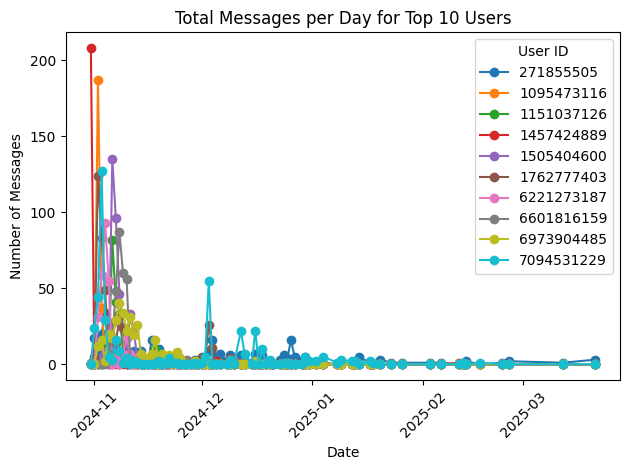

In [10]:
# Plot total messages per day per user for the top 10 users
top_users = user_message_counts.head(10).index
top_users_data = df[df['sender_id'].isin(top_users)]
top_users_data['date'] = top_users_data['date'].dt.date
messages_per_day = top_users_data.groupby(['date', 'sender_id']).size().unstack(fill_value=0)
messages_per_day.plot(kind='line', marker='o')
plt.title('Total Messages per Day for Top 10 Users')
plt.xlabel('Date')
plt.ylabel('Number of Messages')
plt.legend(title='User ID')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Top Users per Channel

In [12]:
# Generate dataframe for each channel
df_general = df[df['topic_name'] == 'Discusión general']
df_bienvenidos = df[df['topic_name'] == 'Bienvenid@s a la Red de Voluntari@s (leed primero)']
df_tranporte = df[df['topic_name'] == 'Transporte de personas a Comunidad Valenciana']
df_grupos_accion = df[df['topic_name'] == 'Grupos de Acción Voluntarios en Terreno']
df_juridica = df[df['topic_name'] == 'Asistencia Jurídica/Seguros']
df_tecnica = df[df['topic_name'] == 'Asistencia Técnica y Maquinaria (mecánica, fontanería, electricidad, agricola)']
df_animales = df[df['topic_name'] == 'Asistencia animales compañia y otros']
df_informatica = df[df['topic_name'] == 'Asistencia Informática/Soporte EAT']
df_logistica = df[df['topic_name'] == 'Logística Interna Valencia(puntos de recepción)']
df_ayudaempresas = df[df['topic_name'] == 'Ayuda de Empresas']
df_investigacion = df[df['topic_name'] == 'Investigación Ciudadana: Responsabilidades Políticas']
df_asistencia_voluntarios = df[df['topic_name'] == 'Asistencia a Voluntarios (Comida y Acogida))']
df_asistencia_vulnerables = df[df['topic_name'] == 'Asis. Grupos Vulnerables (Maternidad , Infancia, Mayores, etc)']
df_material = df[df['topic_name'] == 'Material Video/Fotográfico']
df_webs = df[df['topic_name'] == 'Webs Esenciales']
df_mensajes_ayuda = df[df['topic_name'] == 'Mensajes de Ayuda (Ofrezco/Necesito)']
df_voluntarios_fuera = df[df['topic_name'] == 'Voluntarios de fuera de Valencia (Madrid, Cataluña, Alicante, Castellón)']
df_viviendas = df[df['topic_name'] == 'Viviendas Edificación , Muebles y Acondicionamiento']


In [15]:
# Top 10 users per channel
top_users_general = df_general['sender_id'].value_counts().head(10)
top_users_bienvenidos = df_bienvenidos['sender_id'].value_counts().head(10)
top_users_tranporte = df_tranporte['sender_id'].value_counts().head(10)
top_users_grupos_accion = df_grupos_accion['sender_id'].value_counts().head(10)
top_users_juridica = df_juridica['sender_id'].value_counts().head(10)
top_users_tecnica = df_tecnica['sender_id'].value_counts().head(10)
top_users_animales = df_animales['sender_id'].value_counts().head(10)
top_users_informatica = df_informatica['sender_id'].value_counts().head(10)
top_users_logistica = df_logistica['sender_id'].value_counts().head(10)
top_users_ayudaempresas = df_ayudaempresas['sender_id'].value_counts().head(10)
top_users_investigacion = df_investigacion['sender_id'].value_counts().head(10)
top_users_asistencia_voluntarios = df_asistencia_voluntarios['sender_id'].value_counts().head(10)
top_users_asistencia_vulnerables = df_asistencia_vulnerables['sender_id'].value_counts().head(10)
top_users_material = df_material['sender_id'].value_counts().head(10)
top_users_webs = df_webs['sender_id'].value_counts().head(10)
top_users_mensajes_ayuda = df_mensajes_ayuda['sender_id'].value_counts().head(10)
top_users_voluntarios_fuera = df_voluntarios_fuera['sender_id'].value_counts().head(10)
top_users_viviendas = df_viviendas['sender_id'].value_counts().head(10)

# Show top users for each channel and their message counts
print("Top 10 users in General Discussion:")
print(top_users_general)
print("\nTop 10 users in Bienvenidos:")
print(top_users_bienvenidos)
print("\nTop 10 users in Transporte:")
print(top_users_tranporte)
print("\nTop 10 users in Grupos de Acción:")
print(top_users_grupos_accion)
print("\nTop 10 users in Asistencia Jurídica/Seguros:")
print(top_users_juridica)
print("\nTop 10 users in Asistencia Técnica y Maquinaria:")
print(top_users_tecnica)
print("\nTop 10 users in Asistencia animales compañia y otros:")
print(top_users_animales)
print("\nTop 10 users in Asistencia Informática/Soporte EAT:")
print(top_users_informatica)
print("\nTop 10 users in Logística Interna Valencia:")
print(top_users_logistica)
print("\nTop 10 users in Ayuda de Empresas:")
print(top_users_ayudaempresas)
print("\nTop 10 users in Investigación Ciudadana:")
print(top_users_investigacion)
print("\nTop 10 users in Asistencia a Voluntarios:")
print(top_users_asistencia_voluntarios)
print("\nTop 10 users in Asistencia a Vulnerables:")
print(top_users_asistencia_vulnerables)
print("\nTop 10 users in Material Video/Fotográfico:")
print(top_users_material)
print("\nTop 10 users in Webs Esenciales:")
print(top_users_webs)
print("\nTop 10 users in Mensajes de Ayuda:")
print(top_users_mensajes_ayuda)
print("\nTop 10 users in Voluntarios de fuera de Valencia:")
print(top_users_voluntarios_fuera)
print("\nTop 10 users in Viviendas Edificación , Muebles y Acondicionamiento:")
print(top_users_viviendas)


Top 10 users in General Discussion:
sender_id
1110241832    55
941865373     15
1762777403    13
1662351336    12
1551829597    12
5919794964    11
602365744      9
6618601093     8
5501326376     7
874027536      5
Name: count, dtype: int64

Top 10 users in Bienvenidos:
sender_id
6221273187    87
6601816159    59
5689570195    42
1101084020    35
709835653     31
305217439     29
6743180623    29
5992929865    27
1093909522    24
7861477170    24
Name: count, dtype: int64

Top 10 users in Transporte:
sender_id
1457424889    207
5229698385     65
7472715818     49
5197641355     31
5689570195     27
524281487      24
6929535140     24
1304166575     23
5879036548     22
2047003776     20
Name: count, dtype: int64

Top 10 users in Grupos de Acción:
sender_id
693274644     93
6221273187    57
6601816159    47
1131058651    42
5689570195    32
8144868265    29
5992929865    23
1110241832    22
361288190     16
6973904485    13
Name: count, dtype: int64

Top 10 users in Asistencia Jurídica

### Cross-channel overlap of top users
This section shows which users appear in the top 10 across multiple channels.

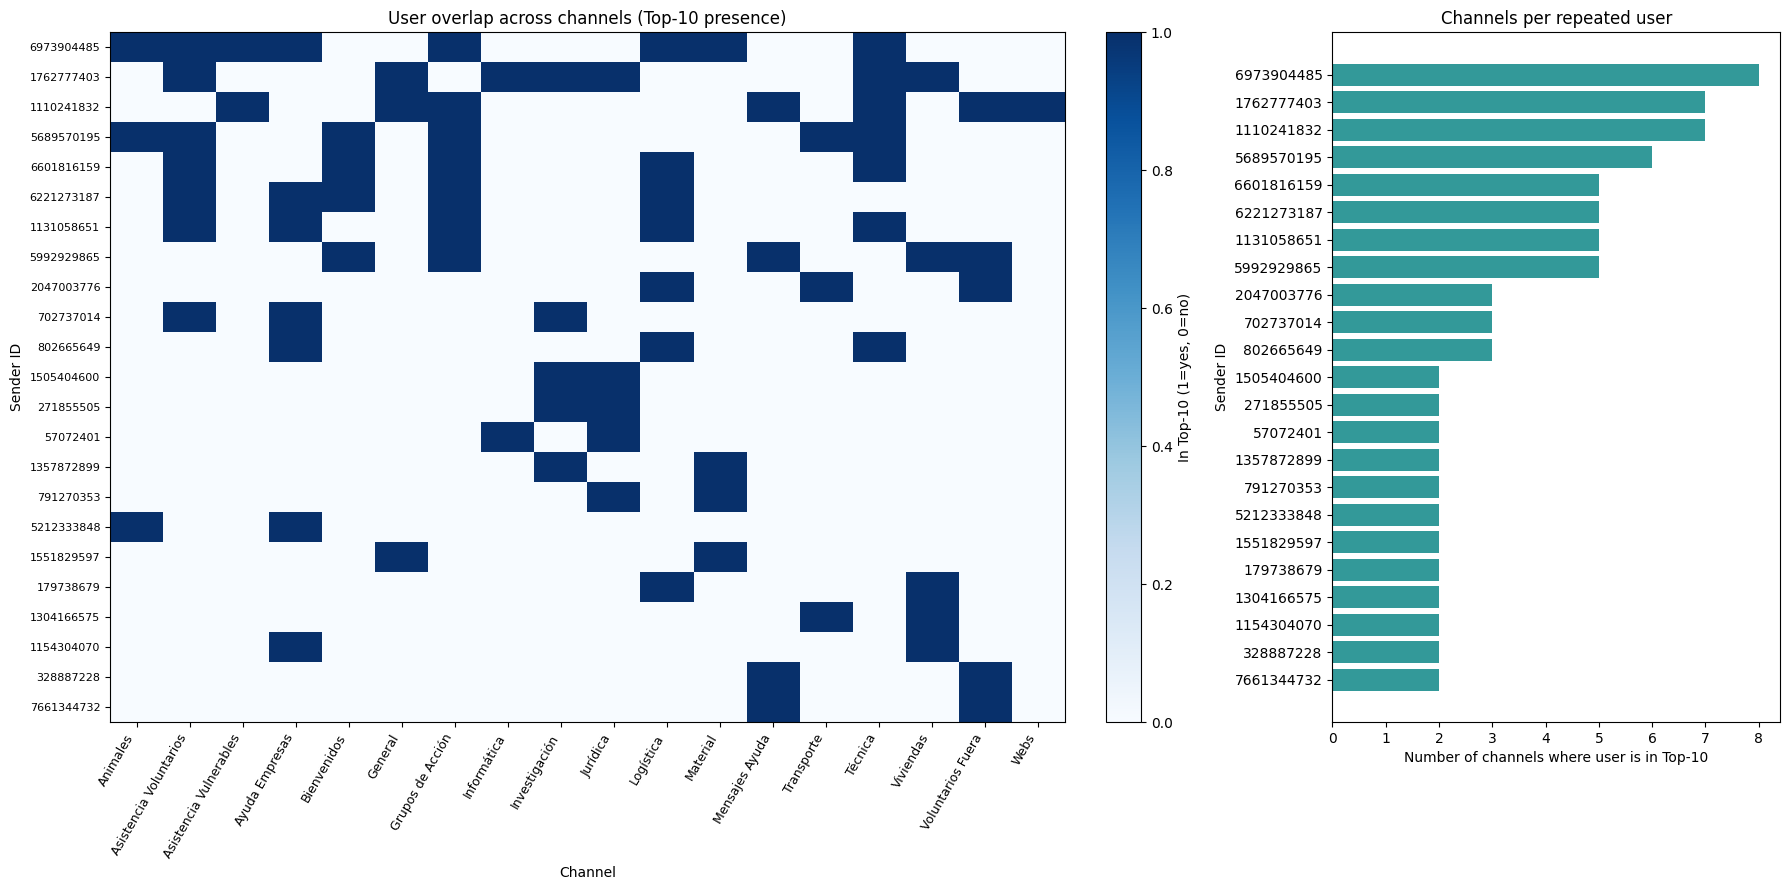

Top repeated users (first 15):


,n_channels,total_top10_msgs
sender_id,,
6973904485,8,256
1762777403,7,363
1110241832,7,117
5689570195,6,192
6601816159,5,284
6221273187,5,235
1131058651,5,109
5992929865,5,84
2047003776,3,142


In [17]:
# Build a unified table of top-10 users across channels and visualize overlap
channel_top_users = {
    'General': top_users_general,
    'Bienvenidos': top_users_bienvenidos,
    'Transporte': top_users_tranporte,
    'Grupos de Acción': top_users_grupos_accion,
    'Jurídica': top_users_juridica,
    'Técnica': top_users_tecnica,
    'Animales': top_users_animales,
    'Informática': top_users_informatica,
    'Logística': top_users_logistica,
    'Ayuda Empresas': top_users_ayudaempresas,
    'Investigación': top_users_investigacion,
    'Asistencia Voluntarios': top_users_asistencia_voluntarios,
    'Asistencia Vulnerables': top_users_asistencia_vulnerables,
    'Material': top_users_material,
    'Webs': top_users_webs,
    'Mensajes Ayuda': top_users_mensajes_ayuda,
    'Voluntarios Fuera': top_users_voluntarios_fuera,
    'Viviendas': top_users_viviendas,
}

records = []
for channel, series in channel_top_users.items():
    for rank, (sender_id, msg_count) in enumerate(series.items(), start=1):
        records.append({
            'channel': channel,
            'sender_id': int(sender_id),
            'rank': rank,
            'msg_count': int(msg_count)
        })

top_users_long = pd.DataFrame(records)

# Presence matrix: 1 if user is in top-10 for that channel, else 0
presence = (
    top_users_long.assign(in_top10=1)
    .pivot_table(index='sender_id', columns='channel', values='in_top10', aggfunc='max', fill_value=0)
    .astype(int)
)

# User-level summary to sort by overlap strength
user_summary = (
    top_users_long.groupby('sender_id', as_index=True)
    .agg(n_channels=('channel', 'nunique'), total_top10_msgs=('msg_count', 'sum'))
    .sort_values(['n_channels', 'total_top10_msgs'], ascending=[False, False])
)

presence = presence.loc[user_summary.index]

# Keep users that appear in at least 2 channels for readability
presence_multi = presence.loc[user_summary['n_channels'] >= 2]
summary_multi = user_summary.loc[user_summary['n_channels'] >= 2]

if presence_multi.empty:
    print('No users appear in top-10 of more than one channel.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(18, 9), gridspec_kw={'width_ratios': [2.8, 1.2]})

    # Heatmap of cross-channel presence
    im = axes[0].imshow(presence_multi.values, aspect='auto', cmap='Blues', vmin=0, vmax=1)
    axes[0].set_title('User overlap across channels (Top-10 presence)')
    axes[0].set_xlabel('Channel')
    axes[0].set_ylabel('Sender ID')
    axes[0].set_xticks(np.arange(presence_multi.shape[1]))
    axes[0].set_xticklabels(presence_multi.columns, rotation=60, ha='right', fontsize=9)
    axes[0].set_yticks(np.arange(presence_multi.shape[0]))
    axes[0].set_yticklabels([str(u) for u in presence_multi.index], fontsize=8)
    cbar = fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
    cbar.set_label('In Top-10 (1=yes, 0=no)')

    # Bar chart: number of channels per repeated user
    axes[1].barh(
        [str(u) for u in summary_multi.index[::-1]],
        summary_multi['n_channels'].values[::-1],
        color='teal',
        alpha=0.8
    )
    axes[1].set_title('Channels per repeated user')
    axes[1].set_xlabel('Number of channels where user is in Top-10')
    axes[1].set_ylabel('Sender ID')

    plt.tight_layout()
    plt.show()

    print('Top repeated users (first 15):')
    display(summary_multi.head(15))

### Sorted channels by similarity + user-channel network
This view clusters channels with similar top-10 user composition and shows a bipartite network of repeated users vs channels.

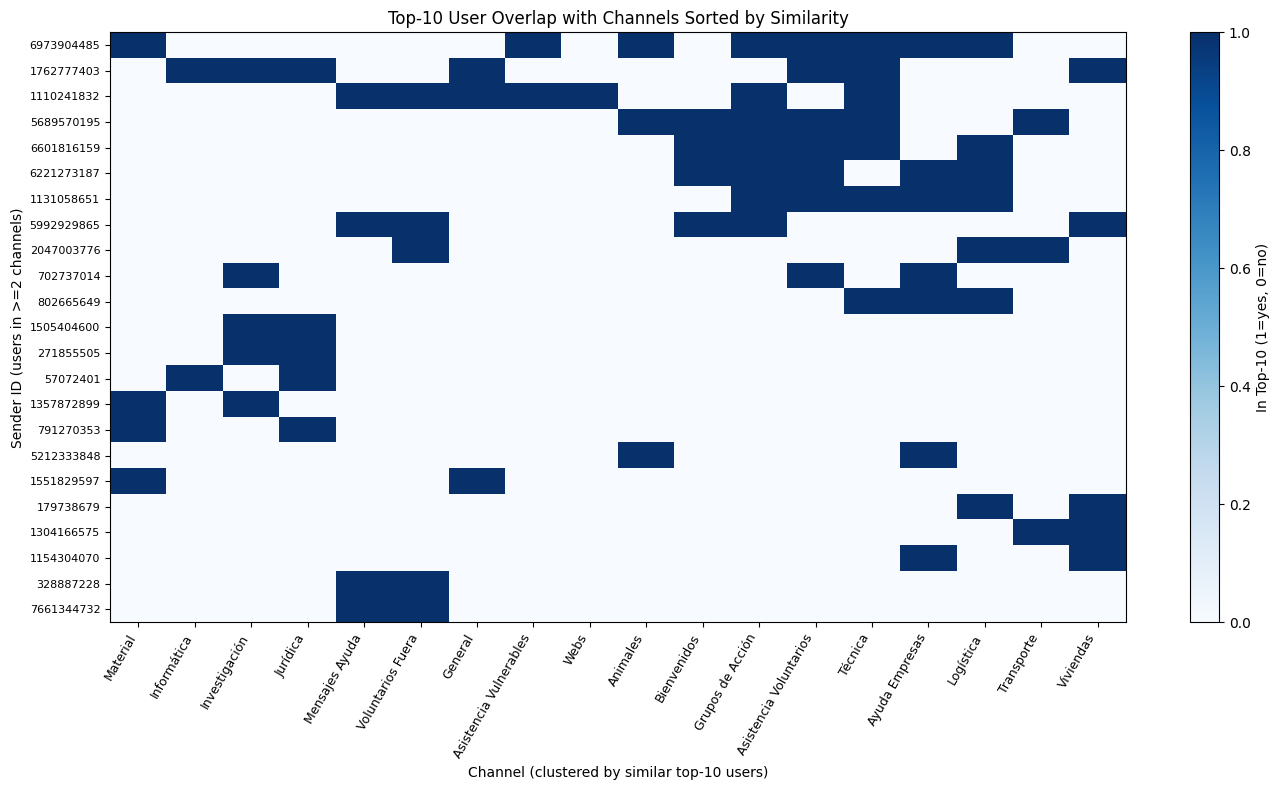

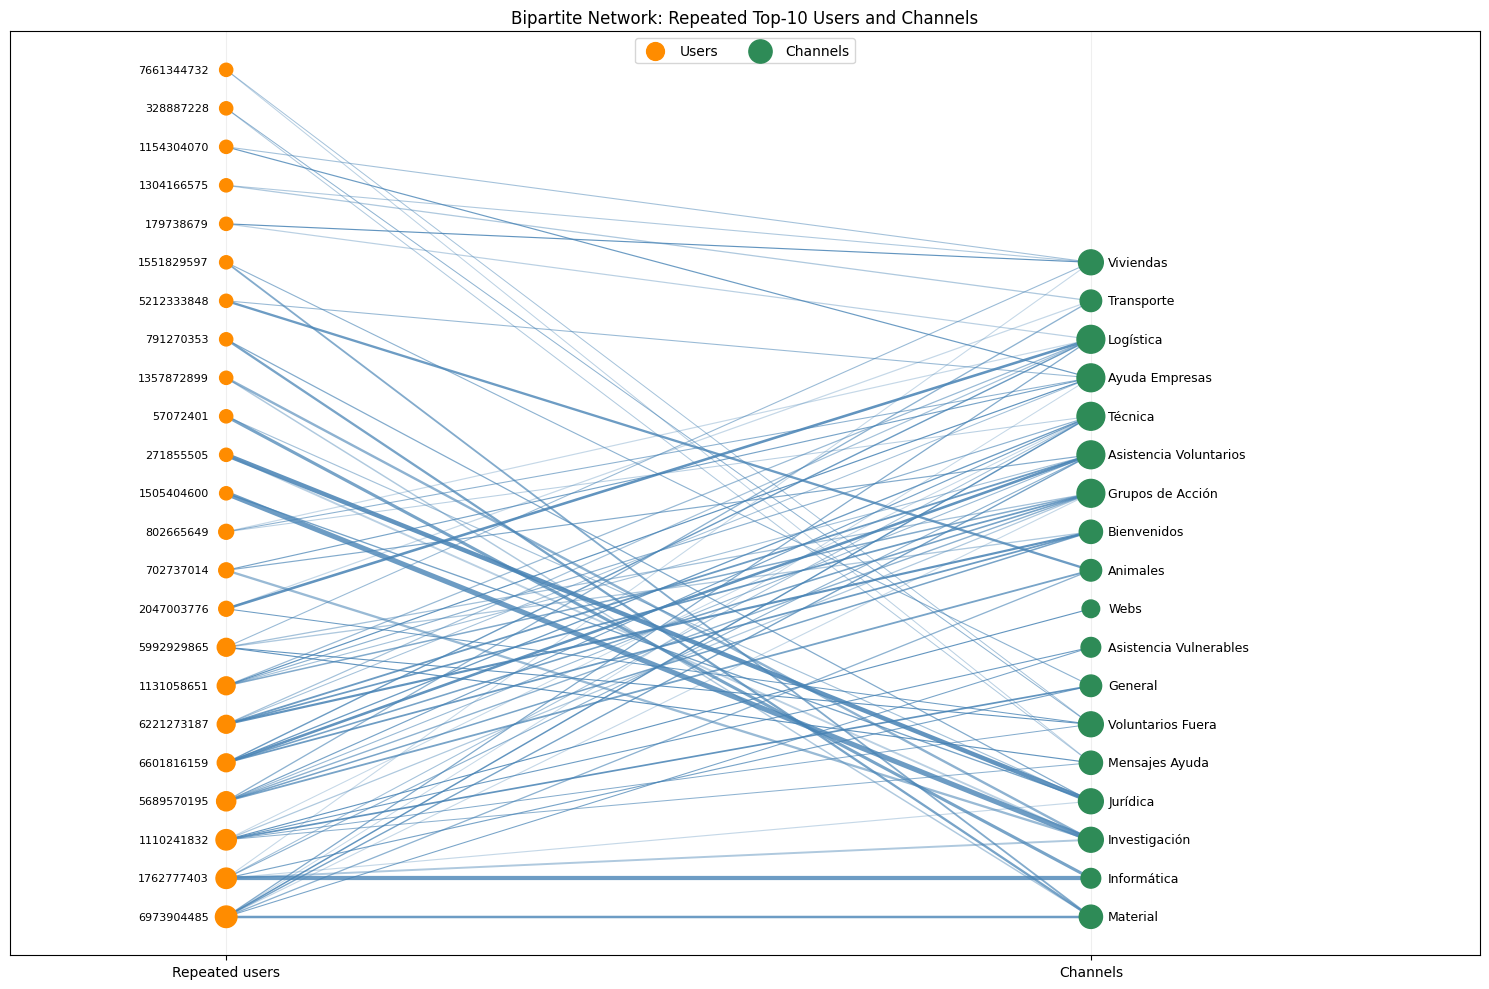

Channels ordered by similarity:
['Material', 'Informática', 'Investigación', 'Jurídica', 'Mensajes Ayuda', 'Voluntarios Fuera', 'General', 'Asistencia Vulnerables', 'Webs', 'Animales', 'Bienvenidos', 'Grupos de Acción', 'Asistencia Voluntarios', 'Técnica', 'Ayuda Empresas', 'Logística', 'Transporte', 'Viviendas']


In [18]:
# Sort channels by similarity, and add a user-channel network plot
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, leaves_list

# Rebuild top-users long table if needed
if 'top_users_long' not in locals():
    channel_top_users = {
        'General': top_users_general,
        'Bienvenidos': top_users_bienvenidos,
        'Transporte': top_users_tranporte,
        'Grupos de Acción': top_users_grupos_accion,
        'Jurídica': top_users_juridica,
        'Técnica': top_users_tecnica,
        'Animales': top_users_animales,
        'Informática': top_users_informatica,
        'Logística': top_users_logistica,
        'Ayuda Empresas': top_users_ayudaempresas,
        'Investigación': top_users_investigacion,
        'Asistencia Voluntarios': top_users_asistencia_voluntarios,
        'Asistencia Vulnerables': top_users_asistencia_vulnerables,
        'Material': top_users_material,
        'Webs': top_users_webs,
        'Mensajes Ayuda': top_users_mensajes_ayuda,
        'Voluntarios Fuera': top_users_voluntarios_fuera,
        'Viviendas': top_users_viviendas,
    }

    records = []
    for channel, series in channel_top_users.items():
        for rank, (sender_id, msg_count) in enumerate(series.items(), start=1):
            records.append({
                'channel': channel,
                'sender_id': int(sender_id),
                'rank': rank,
                'msg_count': int(msg_count)
            })
    top_users_long = pd.DataFrame(records)

# Presence matrix (binary membership in top-10)
presence = (
    top_users_long.assign(in_top10=1)
    .pivot_table(index='sender_id', columns='channel', values='in_top10', aggfunc='max', fill_value=0)
    .astype(int)
)

user_summary = (
    top_users_long.groupby('sender_id', as_index=True)
    .agg(n_channels=('channel', 'nunique'), total_top10_msgs=('msg_count', 'sum'))
    .sort_values(['n_channels', 'total_top10_msgs'], ascending=[False, False])
)

# Keep repeated users for readability
repeated_users = user_summary.index[user_summary['n_channels'] >= 2]
presence_rep = presence.loc[repeated_users]

if presence_rep.empty:
    print('No users appear in top-10 of more than one channel.')
else:
    # Channel ordering by similarity (Jaccard + hierarchical clustering)
    channel_matrix = presence_rep.T.values  # channels x users
    if presence_rep.shape[1] > 1 and presence_rep.shape[0] > 1:
        dist = pdist(channel_matrix, metric='jaccard')
        if np.all(np.isfinite(dist)) and dist.size > 0:
            Z = linkage(dist, method='average')
            ch_order_idx = leaves_list(Z)
            ordered_channels = presence_rep.columns[ch_order_idx]
        else:
            ordered_channels = presence_rep.columns
    else:
        ordered_channels = presence_rep.columns

    presence_sorted = presence_rep[ordered_channels]

    # --- Plot A: heatmap with sorted channels ---
    plt.figure(figsize=(14, 8))
    plt.imshow(presence_sorted.values, aspect='auto', cmap='Blues', vmin=0, vmax=1)
    plt.title('Top-10 User Overlap with Channels Sorted by Similarity')
    plt.xlabel('Channel (clustered by similar top-10 users)')
    plt.ylabel('Sender ID (users in >=2 channels)')
    plt.xticks(np.arange(presence_sorted.shape[1]), presence_sorted.columns, rotation=60, ha='right', fontsize=9)
    plt.yticks(np.arange(presence_sorted.shape[0]), [str(u) for u in presence_sorted.index], fontsize=8)
    cbar = plt.colorbar()
    cbar.set_label('In Top-10 (1=yes, 0=no)')
    plt.tight_layout()
    plt.show()

    # --- Plot B: bipartite network (users <-> channels) ---
    edges = top_users_long[top_users_long['sender_id'].isin(repeated_users)].copy()
    edges = edges[edges['channel'].isin(ordered_channels)].copy()

    user_order = list(user_summary.loc[repeated_users].index)
    channel_order = list(ordered_channels)

    user_y = {u: i for i, u in enumerate(user_order)}
    channel_y = {c: i for i, c in enumerate(channel_order)}

    fig, ax = plt.subplots(figsize=(15, 10))

    x_user = 0.0
    x_channel = 1.0

    # Draw edges (thicker = more messages; more opaque = better rank)
    msg_min = edges['msg_count'].min()
    msg_max = edges['msg_count'].max()
    msg_span = max(1, msg_max - msg_min)

    for _, row in edges.iterrows():
        u = int(row['sender_id'])
        c = row['channel']
        m = int(row['msg_count'])
        r = int(row['rank'])

        y1 = user_y[u]
        y2 = channel_y[c]

        lw = 0.7 + 3.0 * ((m - msg_min) / msg_span)
        alpha = 0.25 + 0.6 * ((11 - r) / 10.0)
        ax.plot([x_user, x_channel], [y1, y2], color='steelblue', linewidth=lw, alpha=alpha)

    # Draw user nodes
    user_sizes = [40 + 25 * user_summary.loc[u, 'n_channels'] for u in user_order]
    ax.scatter([x_user] * len(user_order), list(range(len(user_order))), s=user_sizes, color='darkorange', label='Users', zorder=3)

    # Draw channel nodes
    channel_degree = edges.groupby('channel')['sender_id'].nunique().reindex(channel_order).fillna(0)
    channel_sizes = [120 + 40 * channel_degree.loc[c] for c in channel_order]
    ax.scatter([x_channel] * len(channel_order), list(range(len(channel_order))), s=channel_sizes, color='seagreen', label='Channels', zorder=3)

    # Labels
    for u, y in user_y.items():
        ax.text(x_user - 0.02, y, str(u), ha='right', va='center', fontsize=8)

    for c, y in channel_y.items():
        ax.text(x_channel + 0.02, y, c, ha='left', va='center', fontsize=9)

    ax.set_xlim(-0.25, 1.45)
    ax.set_ylim(-1, max(len(user_order), len(channel_order)))
    ax.set_xticks([x_user, x_channel])
    ax.set_xticklabels(['Repeated users', 'Channels'])
    ax.set_yticks([])
    ax.set_title('Bipartite Network: Repeated Top-10 Users and Channels')
    ax.legend(loc='upper center', ncol=2)
    ax.grid(axis='x', alpha=0.2)

    plt.tight_layout()
    plt.show()

    print('Channels ordered by similarity:')
    print(list(channel_order))

### Two channel clusters based on top-10 users
This first clustering analysis forces a two-cluster split of channels using overlap among the top-10 most active users in each channel. Channels are grouped together when the same users dominate their conversations.

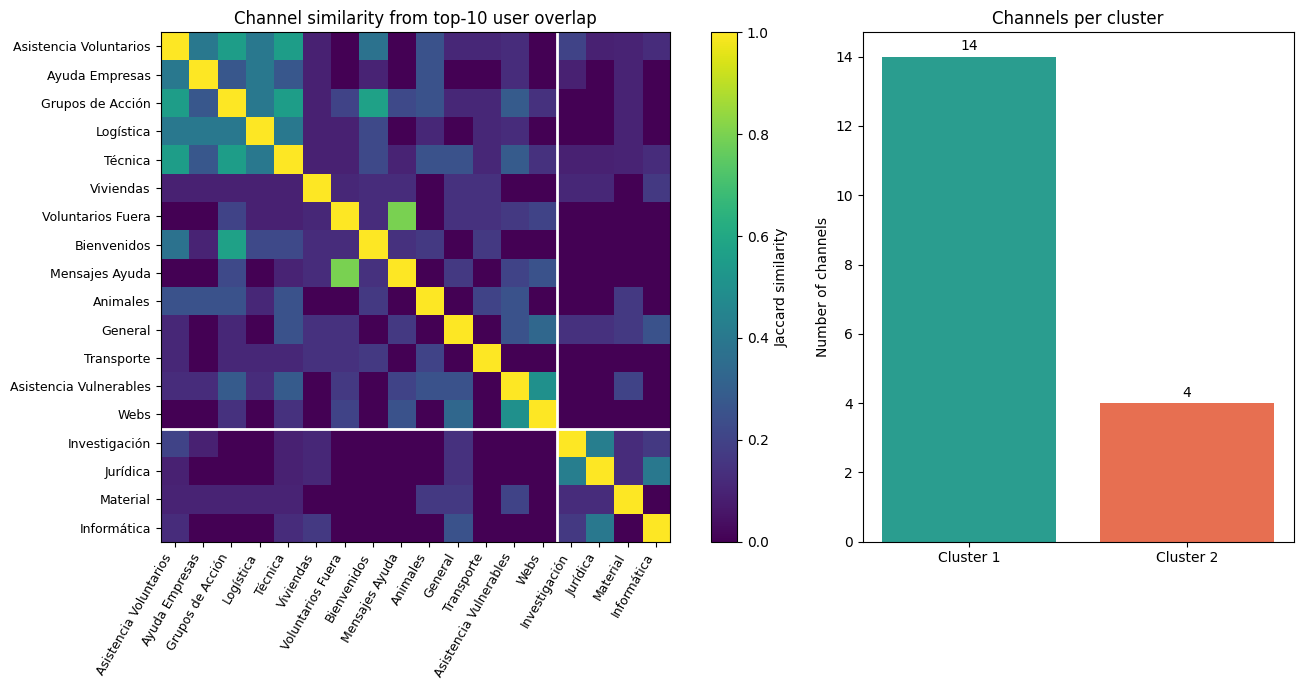

Cluster 1:
['Asistencia Voluntarios', 'Ayuda Empresas', 'Grupos de Acción', 'Logística', 'Técnica', 'Viviendas', 'Voluntarios Fuera', 'Bienvenidos', 'Mensajes Ayuda', 'Animales', 'General', 'Transporte', 'Asistencia Vulnerables', 'Webs']

Cluster 2:
['Investigación', 'Jurídica', 'Material', 'Informática']



,channel,cluster,repeated_top_users
0,Asistencia Voluntarios,1,7
1,Ayuda Empresas,1,7
2,Grupos de Acción,1,7
3,Logística,1,7
4,Técnica,1,7
5,Viviendas,1,5
6,Voluntarios Fuera,1,5
7,Bienvenidos,1,4
8,Mensajes Ayuda,1,4
9,Animales,1,3


In [21]:
# Force channels into two clusters using overlap among top-10 users
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import AgglomerativeClustering

if 'top_users_long' not in locals():
    channel_top_users = {
        'General': top_users_general,
        'Bienvenidos': top_users_bienvenidos,
        'Transporte': top_users_tranporte,
        'Grupos de Acción': top_users_grupos_accion,
        'Jurídica': top_users_juridica,
        'Técnica': top_users_tecnica,
        'Animales': top_users_animales,
        'Informática': top_users_informatica,
        'Logística': top_users_logistica,
        'Ayuda Empresas': top_users_ayudaempresas,
        'Investigación': top_users_investigacion,
        'Asistencia Voluntarios': top_users_asistencia_voluntarios,
        'Asistencia Vulnerables': top_users_asistencia_vulnerables,
        'Material': top_users_material,
        'Webs': top_users_webs,
        'Mensajes Ayuda': top_users_mensajes_ayuda,
        'Voluntarios Fuera': top_users_voluntarios_fuera,
        'Viviendas': top_users_viviendas,
    }

    records = []
    for channel, series in channel_top_users.items():
        for rank, (sender_id, msg_count) in enumerate(series.items(), start=1):
            records.append({
                'channel': channel,
                'sender_id': int(sender_id),
                'rank': rank,
                'msg_count': int(msg_count)
            })
    top_users_long = pd.DataFrame(records)

presence = (
    top_users_long.assign(in_top10=1)
    .pivot_table(index='sender_id', columns='channel', values='in_top10', aggfunc='max', fill_value=0)
    .astype(int)
 )

user_summary = (
    top_users_long.groupby('sender_id', as_index=True)
    .agg(n_channels=('channel', 'nunique'), total_top10_msgs=('msg_count', 'sum'))
    .sort_values(['n_channels', 'total_top10_msgs'], ascending=[False, False])
 )

repeated_users = user_summary.index[user_summary['n_channels'] >= 2]
presence_rep = presence.loc[repeated_users]

if presence_rep.shape[1] < 2:
    print('At least two channels are required to build two clusters.')
elif presence_rep.shape[0] == 0:
    print('No repeated users appear in top-10 of multiple channels, so the two-cluster split is not informative.')
else:
    channel_matrix = presence_rep.T.astype(bool)
    distance_matrix = squareform(pdist(channel_matrix.values, metric='jaccard'))

    if not np.all(np.isfinite(distance_matrix)):
        print('The distance matrix contains invalid values, so clustering could not be computed.')
    elif np.allclose(distance_matrix, 0):
        print('All channels have the same repeated-user profile, so a two-cluster split would be arbitrary.')
    else:
        model = AgglomerativeClustering(n_clusters=2, metric='precomputed', linkage='average')
        cluster_labels = model.fit_predict(distance_matrix) + 1

        cluster_df_top10 = (
            pd.DataFrame({
                'channel': presence_rep.columns,
                'cluster': cluster_labels,
                'repeated_top_users': presence_rep.sum(axis=0).reindex(presence_rep.columns).values
            })
            .sort_values(['cluster', 'repeated_top_users', 'channel'], ascending=[True, False, True])
            .reset_index(drop=True)
        )

        ordered_channels = cluster_df_top10['channel'].tolist()
        similarity_matrix = pd.DataFrame(
            1 - distance_matrix,
            index=presence_rep.columns,
            columns=presence_rep.columns
        )
        similarity_sorted = similarity_matrix.loc[ordered_channels, ordered_channels]

        fig, axes = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [2.4, 1]})

        im = axes[0].imshow(similarity_sorted.values, cmap='viridis', vmin=0, vmax=1)
        axes[0].set_title('Channel similarity from top-10 user overlap')
        axes[0].set_xticks(np.arange(len(ordered_channels)))
        axes[0].set_xticklabels(ordered_channels, rotation=60, ha='right', fontsize=9)
        axes[0].set_yticks(np.arange(len(ordered_channels)))
        axes[0].set_yticklabels(ordered_channels, fontsize=9)
        cbar = fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
        cbar.set_label('Jaccard similarity')

        first_cluster_size = (cluster_df_top10['cluster'] == 1).sum()
        if 0 < first_cluster_size < len(ordered_channels):
            axes[0].axhline(first_cluster_size - 0.5, color='white', linewidth=2)
            axes[0].axvline(first_cluster_size - 0.5, color='white', linewidth=2)

        cluster_sizes = cluster_df_top10['cluster'].value_counts().reindex([1, 2], fill_value=0)
        axes[1].bar(['Cluster 1', 'Cluster 2'], cluster_sizes.values, color=['#2a9d8f', '#e76f51'])
        axes[1].set_title('Channels per cluster')
        axes[1].set_ylabel('Number of channels')
        for idx, count in enumerate(cluster_sizes.values):
            axes[1].text(idx, count + 0.1, str(int(count)), ha='center', va='bottom')

        plt.tight_layout()
        plt.show()

        print('Cluster 1:')
        print(cluster_df_top10.loc[cluster_df_top10['cluster'] == 1, 'channel'].tolist())
        print()
        print('Cluster 2:')
        print(cluster_df_top10.loc[cluster_df_top10['cluster'] == 2, 'channel'].tolist())
        print()
        display(cluster_df_top10)

### Two channel clusters based on all users
This second clustering analysis forces a two-cluster split of channels using the full distribution of messages per user in each channel. Two channels are grouped together when their overall user activity profiles are similar, not only when they share the same top-10 users.

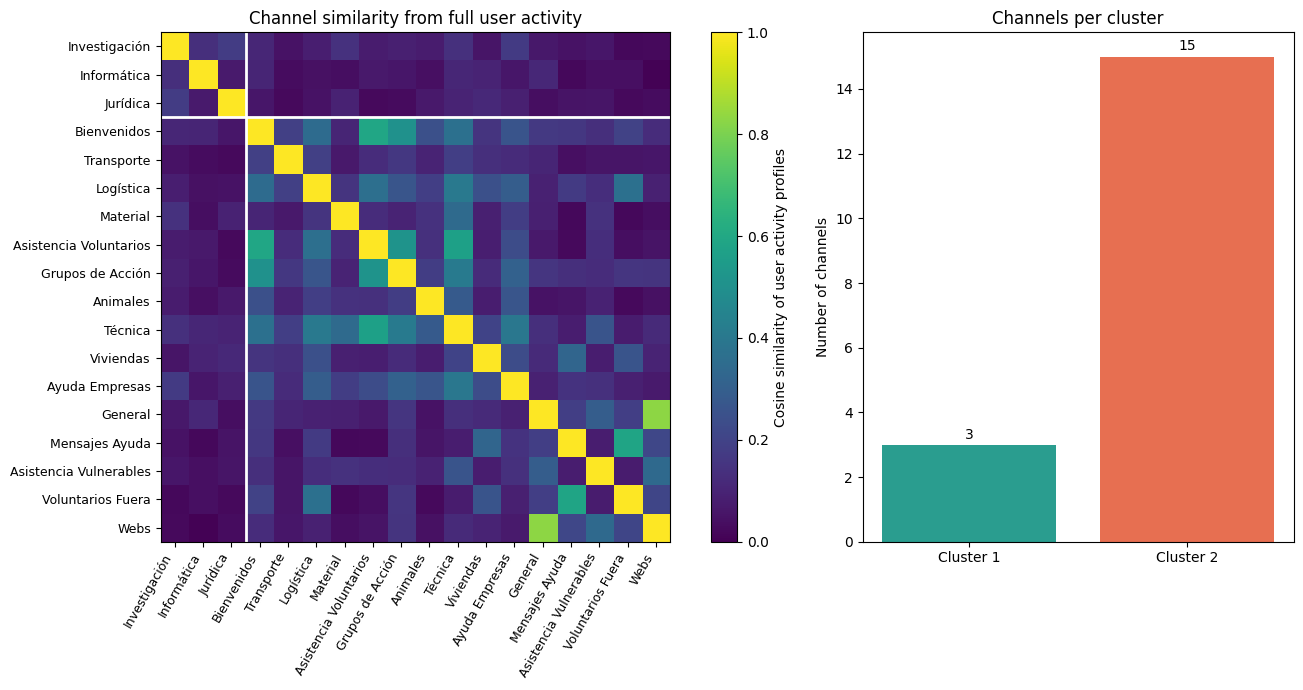

Cluster 1:
['Investigación', 'Informática', 'Jurídica']

Cluster 2:
['Bienvenidos', 'Transporte', 'Logística', 'Material', 'Asistencia Voluntarios', 'Grupos de Acción', 'Animales', 'Técnica', 'Viviendas', 'Ayuda Empresas', 'General', 'Mensajes Ayuda', 'Asistencia Vulnerables', 'Voluntarios Fuera', 'Webs']



,channel,cluster,total_messages,active_users
0,Investigación,1,2770,331
1,Informática,1,1964,234
2,Jurídica,1,819,149
3,Bienvenidos,2,2856,1215
4,Transporte,2,2076,649
5,Logística,2,1307,409
6,Material,2,1170,195
7,Asistencia Voluntarios,2,1163,434
8,Grupos de Acción,2,1052,340
9,Animales,2,1033,246


In [20]:
# Force channels into two clusters using full user activity similarity
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import AgglomerativeClustering

channel_frames = {
    'General': df_general,
    'Bienvenidos': df_bienvenidos,
    'Transporte': df_tranporte,
    'Grupos de Acción': df_grupos_accion,
    'Jurídica': df_juridica,
    'Técnica': df_tecnica,
    'Animales': df_animales,
    'Informática': df_informatica,
    'Logística': df_logistica,
    'Ayuda Empresas': df_ayudaempresas,
    'Investigación': df_investigacion,
    'Asistencia Voluntarios': df_asistencia_voluntarios,
    'Asistencia Vulnerables': df_asistencia_vulnerables,
    'Material': df_material,
    'Webs': df_webs,
    'Mensajes Ayuda': df_mensajes_ayuda,
    'Voluntarios Fuera': df_voluntarios_fuera,
    'Viviendas': df_viviendas,
}

channel_activity = (
    pd.concat(
        [
            frame.groupby('sender_id').size().rename(channel_name)
            for channel_name, frame in channel_frames.items()
        ],
        axis=1
    )
    .T
    .fillna(0)
    .astype(float)
 )

if channel_activity.shape[0] < 2:
    print('At least two channels are required to build two clusters.')
else:
    channel_totals = channel_activity.sum(axis=1)
    non_empty_channels = channel_totals[channel_totals > 0].index

    if len(non_empty_channels) < 2:
        print('At least two non-empty channels are required to build two clusters.')
    else:
        channel_activity = channel_activity.loc[non_empty_channels]
        channel_totals = channel_activity.sum(axis=1)
        active_users_per_channel = (channel_activity > 0).sum(axis=1)

        # Normalize within each channel so similarity reflects user participation structure, not channel size.
        activity_profiles = channel_activity.div(channel_totals, axis=0)
        distance_matrix = squareform(pdist(activity_profiles.values, metric='cosine'))

        if not np.all(np.isfinite(distance_matrix)):
            print('The distance matrix contains invalid values, so clustering could not be computed.')
        elif np.allclose(distance_matrix, 0):
            print('All channels have the same user activity profile, so a two-cluster split would be arbitrary.')
        else:
            model = AgglomerativeClustering(n_clusters=2, metric='precomputed', linkage='average')
            cluster_labels = model.fit_predict(distance_matrix) + 1

            cluster_df = (
                pd.DataFrame({
                    'channel': channel_activity.index,
                    'cluster': cluster_labels,
                    'total_messages': channel_totals.values.astype(int),
                    'active_users': active_users_per_channel.values.astype(int)
                })
                .sort_values(['cluster', 'total_messages', 'active_users', 'channel'], ascending=[True, False, False, True])
                .reset_index(drop=True)
            )

            ordered_channels = cluster_df['channel'].tolist()
            similarity_matrix = pd.DataFrame(
                1 - distance_matrix,
                index=channel_activity.index,
                columns=channel_activity.index
            )
            similarity_sorted = similarity_matrix.loc[ordered_channels, ordered_channels]

            fig, axes = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [2.4, 1]})

            im = axes[0].imshow(similarity_sorted.values, cmap='viridis', vmin=0, vmax=1)
            axes[0].set_title('Channel similarity from full user activity')
            axes[0].set_xticks(np.arange(len(ordered_channels)))
            axes[0].set_xticklabels(ordered_channels, rotation=60, ha='right', fontsize=9)
            axes[0].set_yticks(np.arange(len(ordered_channels)))
            axes[0].set_yticklabels(ordered_channels, fontsize=9)
            cbar = fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
            cbar.set_label('Cosine similarity of user activity profiles')

            first_cluster_size = (cluster_df['cluster'] == 1).sum()
            if 0 < first_cluster_size < len(ordered_channels):
                axes[0].axhline(first_cluster_size - 0.5, color='white', linewidth=2)
                axes[0].axvline(first_cluster_size - 0.5, color='white', linewidth=2)

            cluster_sizes = cluster_df['cluster'].value_counts().reindex([1, 2], fill_value=0)
            axes[1].bar(['Cluster 1', 'Cluster 2'], cluster_sizes.values, color=['#2a9d8f', '#e76f51'])
            axes[1].set_title('Channels per cluster')
            axes[1].set_ylabel('Number of channels')
            for idx, count in enumerate(cluster_sizes.values):
                axes[1].text(idx, count + 0.1, str(int(count)), ha='center', va='bottom')

            plt.tight_layout()
            plt.show()

            print('Cluster 1:')
            print(cluster_df.loc[cluster_df['cluster'] == 1, 'channel'].tolist())
            print()
            print('Cluster 2:')
            print(cluster_df.loc[cluster_df['cluster'] == 2, 'channel'].tolist())
            print()
            display(cluster_df)

### Divide into 4 Clusters
From the heat map it is visible that there may be a third and fourth cluster in the center (and informatics). Let's try to divide them into three.

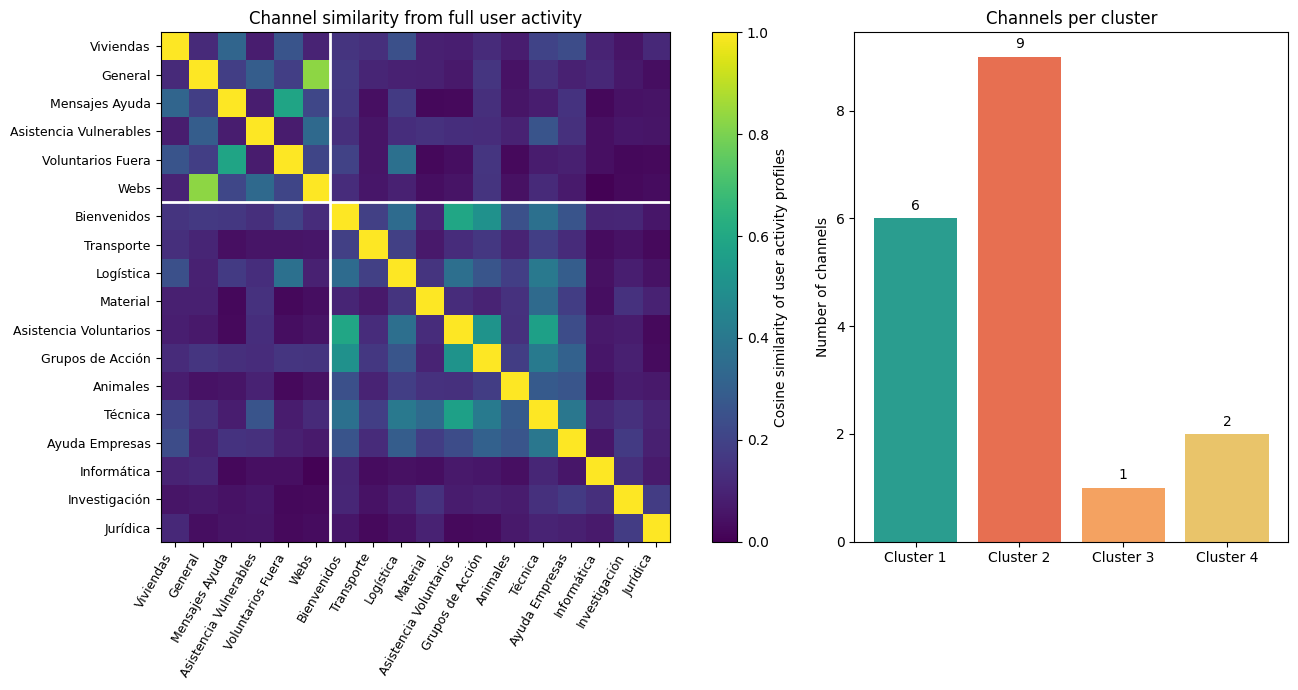

Cluster 1:
['Viviendas', 'General', 'Mensajes Ayuda', 'Asistencia Vulnerables', 'Voluntarios Fuera', 'Webs']

Cluster 2:
['Bienvenidos', 'Transporte', 'Logística', 'Material', 'Asistencia Voluntarios', 'Grupos de Acción', 'Animales', 'Técnica', 'Ayuda Empresas']

Cluster 3:
['Informática']

Cluster 4:
['Investigación', 'Jurídica']



,channel,cluster,total_messages,active_users
0,Viviendas,1,428,149
1,General,1,256,59
2,Mensajes Ayuda,1,175,85
3,Asistencia Vulnerables,1,144,64
4,Voluntarios Fuera,1,51,24
5,Webs,1,12,1
6,Bienvenidos,2,2856,1215
7,Transporte,2,2076,649
8,Logística,2,1307,409
9,Material,2,1170,195


In [23]:
# Force channels into four clusters using full user activity similarity
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import AgglomerativeClustering

channel_frames = {
    'General': df_general,
    'Bienvenidos': df_bienvenidos,
    'Transporte': df_tranporte,
    'Grupos de Acción': df_grupos_accion,
    'Jurídica': df_juridica,
    'Técnica': df_tecnica,
    'Animales': df_animales,
    'Informática': df_informatica,
    'Logística': df_logistica,
    'Ayuda Empresas': df_ayudaempresas,
    'Investigación': df_investigacion,
    'Asistencia Voluntarios': df_asistencia_voluntarios,
    'Asistencia Vulnerables': df_asistencia_vulnerables,
    'Material': df_material,
    'Webs': df_webs,
    'Mensajes Ayuda': df_mensajes_ayuda,
    'Voluntarios Fuera': df_voluntarios_fuera,
    'Viviendas': df_viviendas,
}

channel_activity = (
    pd.concat(
        [
            frame.groupby('sender_id').size().rename(channel_name)
            for channel_name, frame in channel_frames.items()
        ],
        axis=1
    )
    .T
    .fillna(0)
    .astype(float)
 )

if channel_activity.shape[0] < 4:
    print('At least four channels are required to build four clusters.')
else:
    channel_totals = channel_activity.sum(axis=1)
    non_empty_channels = channel_totals[channel_totals > 0].index

    if len(non_empty_channels) < 4:
        print('At least four non-empty channels are required to build four clusters.')
    else:
        channel_activity = channel_activity.loc[non_empty_channels]
        channel_totals = channel_activity.sum(axis=1)
        active_users_per_channel = (channel_activity > 0).sum(axis=1)

        # Normalize within each channel so similarity reflects user participation structure, not channel size.
        activity_profiles = channel_activity.div(channel_totals, axis=0)
        distance_matrix = squareform(pdist(activity_profiles.values, metric='cosine'))

        if not np.all(np.isfinite(distance_matrix)):
            print('The distance matrix contains invalid values, so clustering could not be computed.')
        elif np.allclose(distance_matrix, 0):
            print('All channels have the same user activity profile, so a four-cluster split would be arbitrary.')
        else:
            model = AgglomerativeClustering(n_clusters=4, metric='precomputed', linkage='average')
            cluster_labels = model.fit_predict(distance_matrix) + 1

            cluster_df = (
                pd.DataFrame({
                    'channel': channel_activity.index,
                    'cluster': cluster_labels,
                    'total_messages': channel_totals.values.astype(int),
                    'active_users': active_users_per_channel.values.astype(int)
                })
                .sort_values(['cluster', 'total_messages', 'active_users', 'channel'], ascending=[True, False, False, True])
                .reset_index(drop=True)
            )

            ordered_channels = cluster_df['channel'].tolist()
            similarity_matrix = pd.DataFrame(
                1 - distance_matrix,
                index=channel_activity.index,
                columns=channel_activity.index
            )
            similarity_sorted = similarity_matrix.loc[ordered_channels, ordered_channels]

            fig, axes = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [2.4, 1]})

            im = axes[0].imshow(similarity_sorted.values, cmap='viridis', vmin=0, vmax=1)
            axes[0].set_title('Channel similarity from full user activity')
            axes[0].set_xticks(np.arange(len(ordered_channels)))
            axes[0].set_xticklabels(ordered_channels, rotation=60, ha='right', fontsize=9)
            axes[0].set_yticks(np.arange(len(ordered_channels)))
            axes[0].set_yticklabels(ordered_channels, fontsize=9)
            cbar = fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
            cbar.set_label('Cosine similarity of user activity profiles')

            first_cluster_size = (cluster_df['cluster'] == 1).sum()
            if 0 < first_cluster_size < len(ordered_channels):
                axes[0].axhline(first_cluster_size - 0.5, color='white', linewidth=2)
                axes[0].axvline(first_cluster_size - 0.5, color='white', linewidth=2)

            cluster_sizes = cluster_df['cluster'].value_counts().reindex([1, 2, 3, 4], fill_value=0)
            axes[1].bar(['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4'], cluster_sizes.values, color=['#2a9d8f', '#e76f51', '#f4a261', '#e9c46a'])
            axes[1].set_title('Channels per cluster')
            axes[1].set_ylabel('Number of channels')
            for idx, count in enumerate(cluster_sizes.values):
                axes[1].text(idx, count + 0.1, str(int(count)), ha='center', va='bottom')

            plt.tight_layout()
            plt.show()

            print('Cluster 1:')
            print(cluster_df.loc[cluster_df['cluster'] == 1, 'channel'].tolist())
            print()
            print('Cluster 2:')
            print(cluster_df.loc[cluster_df['cluster'] == 2, 'channel'].tolist())
            print()
            print('Cluster 3:')
            print(cluster_df.loc[cluster_df['cluster'] == 3, 'channel'].tolist())
            print()
            print('Cluster 4:')
            print(cluster_df.loc[cluster_df['cluster'] == 4, 'channel'].tolist())
            print()
            display(cluster_df)